# Análisis estadístico de los datos

Analizamos las variables del dataset [Project management Risk Raw](https://www.kaggle.com/datasets/ka66ledata/project-management-risk-raw/data), disponible públicamente en Kaggle.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import seaborn as sns
import os
import kagglehub
from matplotlib.colors import to_rgba
from pathlib import Path

## Cargamos el dataset

In [7]:
file_path = Path("../data/processed/project_risk_clean.csv")
df = pd.read_csv(file_path)

## EDA

Analizamos las características de nuestro dataset y dividimos el análisis en dos: uno para variables numéricas y otro para variables categóricas.

En total, tenemos 51 columnas, donde 25 son numéricas (int64 o float64) y 26 son objetos, incluyendo esta última el nivel de riesgo (Risk_Level).

Para poder analizar la correlación del nivel del riesgo con las variables numéricas, realizamos un mapeo de la característica, ponderando de menor a mayor riesgo con enteros consecutivos.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Project_ID                       4000 non-null   object 
 1   Project_Type                     4000 non-null   object 
 2   Team_Size                        4000 non-null   int64  
 3   Project_Budget_USD               4000 non-null   float64
 4   Estimated_Timeline_Months        4000 non-null   int64  
 5   Complexity_Score                 4000 non-null   float64
 6   Stakeholder_Count                4000 non-null   int64  
 7   Methodology_Used                 4000 non-null   object 
 8   Team_Experience_Level            4000 non-null   object 
 9   Past_Similar_Projects            4000 non-null   int64  
 10  External_Dependencies_Count      4000 non-null   int64  
 11  Change_Request_Frequency         4000 non-null   float64
 12  Project_Phase       

In [9]:
data = df.copy()
data["Risk_Level"] = data["Risk_Level"].replace({
    'Low' : 1,
    'Medium' : 2,
    'High' : 3,
    'Critical' : 4
}).astype("int")

/tmp/ipykernel_1169845/2061717795.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Risk_Level"] = data["Risk_Level"].replace({


In [10]:
df_category = df.select_dtypes(include=['object']).copy()
df_numeric = data.select_dtypes(include=['int64', 'float64']).copy()

### Variables numéricas

Primero, realizamos un mapa de calor para representar la correlación de todas las variables numéricas, donde la última representa el nivel de riesgo mapeado.

Segundo, analizamos la frecuencia de cada valor de las variables, pudiendo observar tanto la magnitud de los valores que toman como  la cantidad de ocurrencias de cada uno.

Luego, realizamos un análisis de la variabilidad de los valores mediante un boxplot, separando las variables en tres según la magnitud máxima: uno para las variables con valores menores a 1.5, otro para las variables con valores menores a 10 y el último para las variables con valores menores a 50.

Finalmente, analizamos cómo se modifican las distribuciones de las variables numéricas al segmentar el análisis por nivel de riesgo. Para mejor visualización, utilizamos unicamente 8 bins.

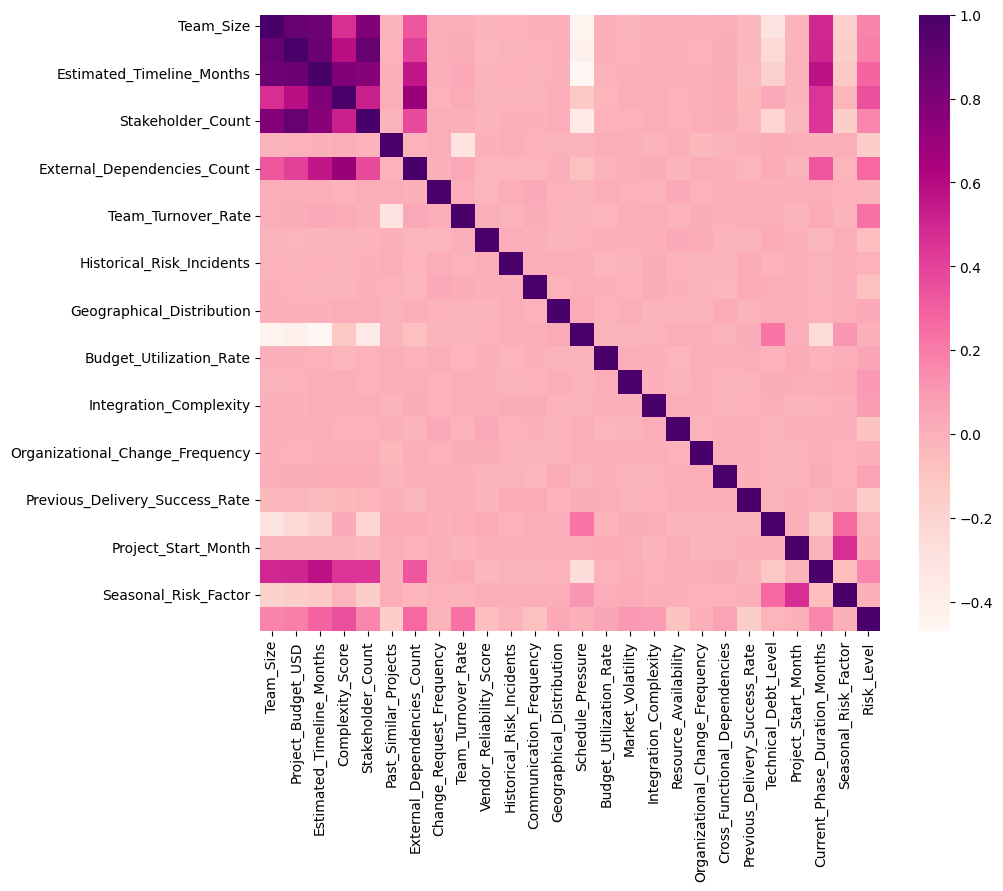

In [11]:
fig, axs = plt.subplots(1)

sns.heatmap(df_numeric.corr(), ax=axs, cmap="RdPu")
fig.set_size_inches(10, 8)
plt.show()

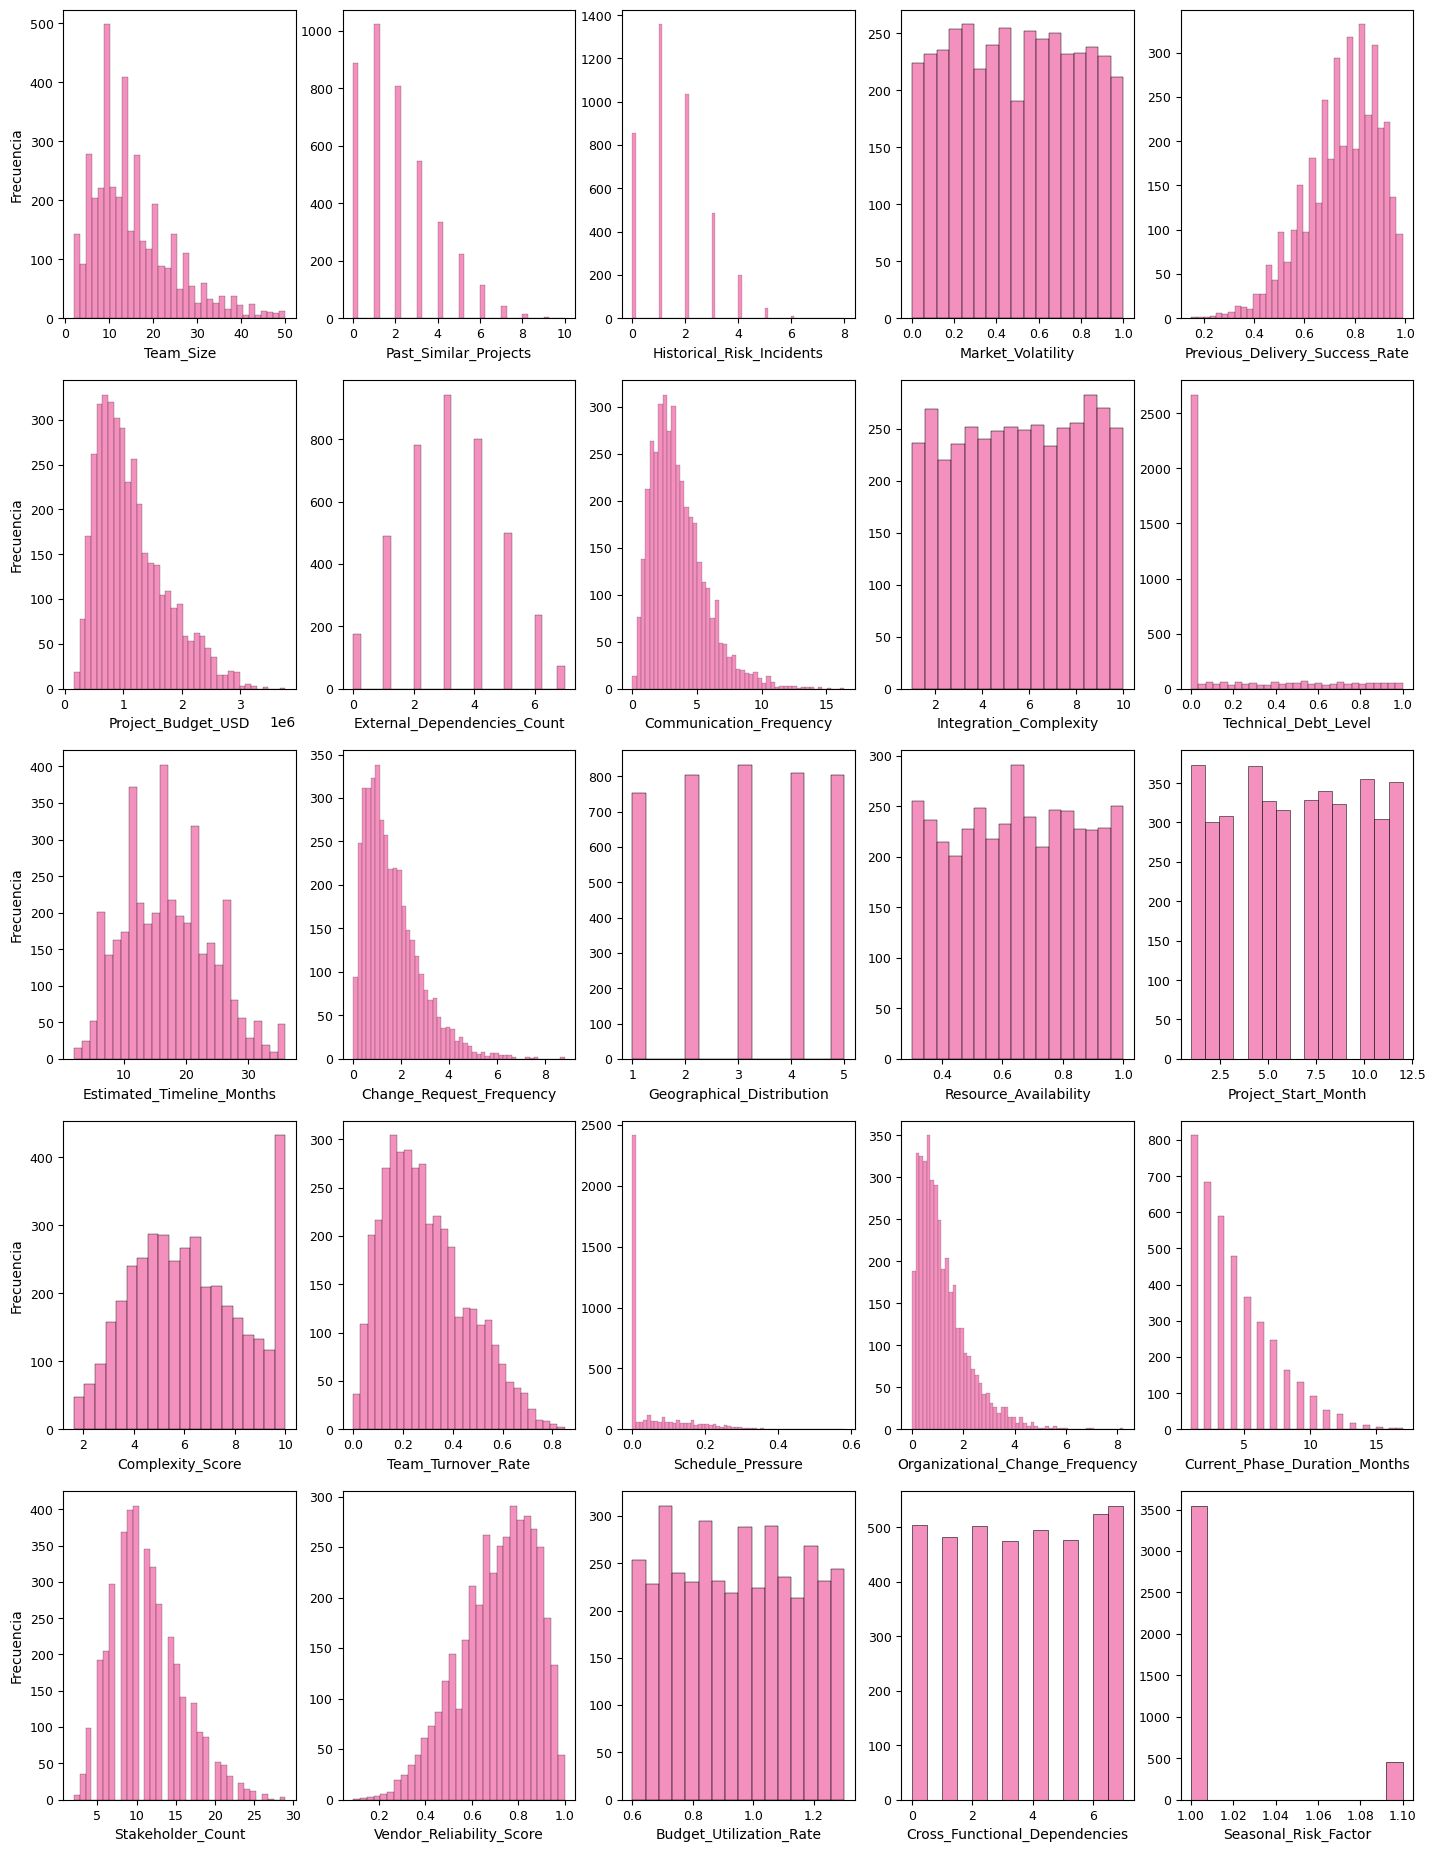

In [12]:
fig, axs = plt.subplots(5, 5)

for i in range(5):
    for j in range(5):
        col = df_numeric.columns[5*j+i]
        sns.histplot(data=df_numeric, x=col, ax=axs[i, j], color='#F06BA9')
        if j == 0:
            axs[i, j].set_ylabel('Frecuencia', fontsize=10)
        else:
            axs[i,j].set_ylabel('')
        axs[i, j].tick_params(axis='both', labelsize=9)


fig.set_size_inches(20, 10)
plt.subplots_adjust(right=0.8, top=1.9)
plt.show()

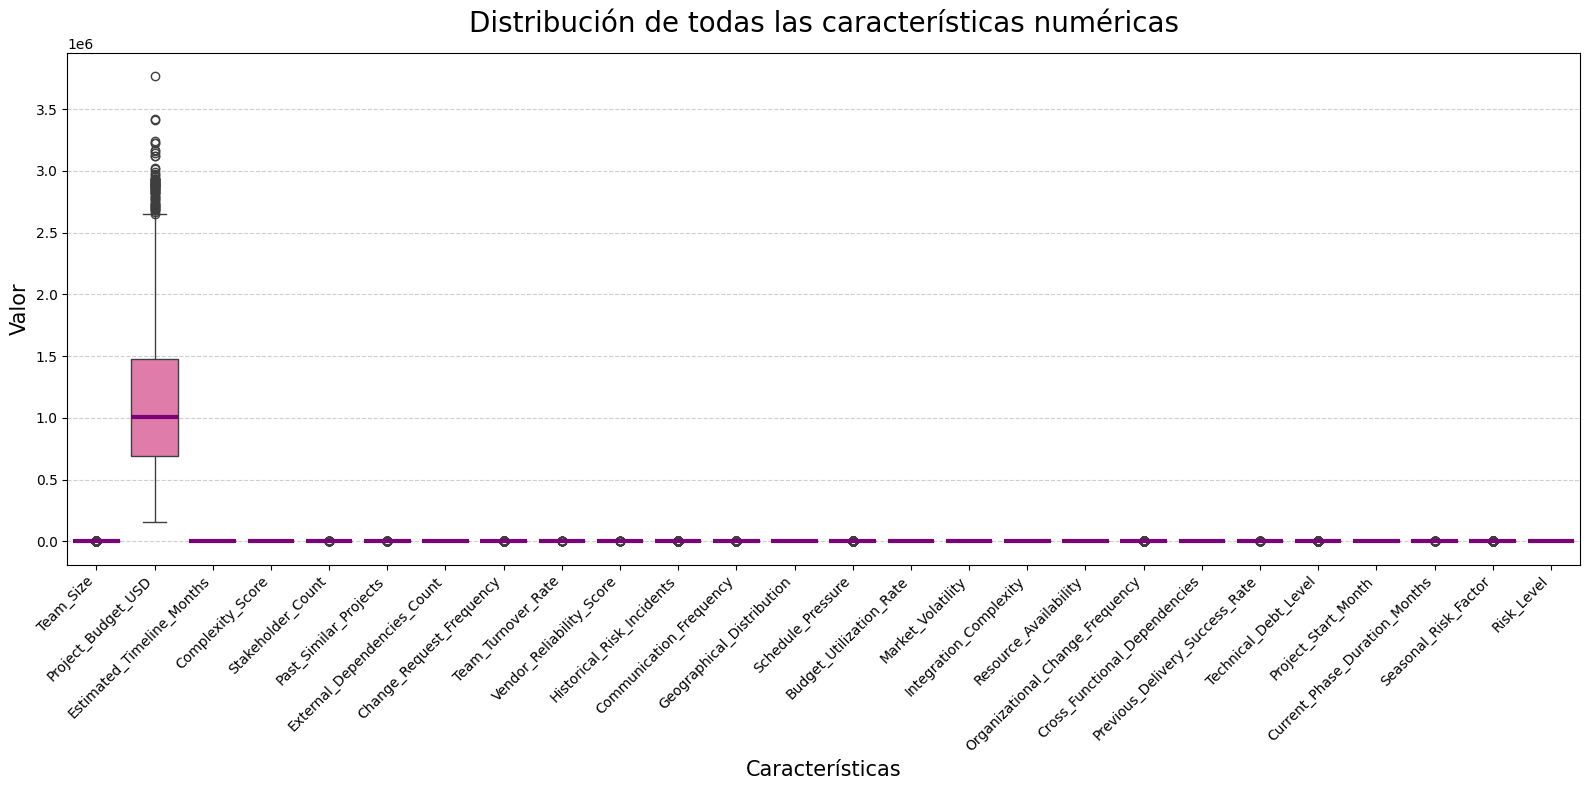

In [13]:
plt.figure(figsize=(16, 8))

medprops = {'linewidth': 3, 'color': '#7A0177'}

sns.boxplot(data=df_numeric, color = '#F06BA9', medianprops=medprops)

plt.title('Distribución de todas las características numéricas', fontsize=20, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylabel('Valor', fontsize=15)
plt.xlabel('Características', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

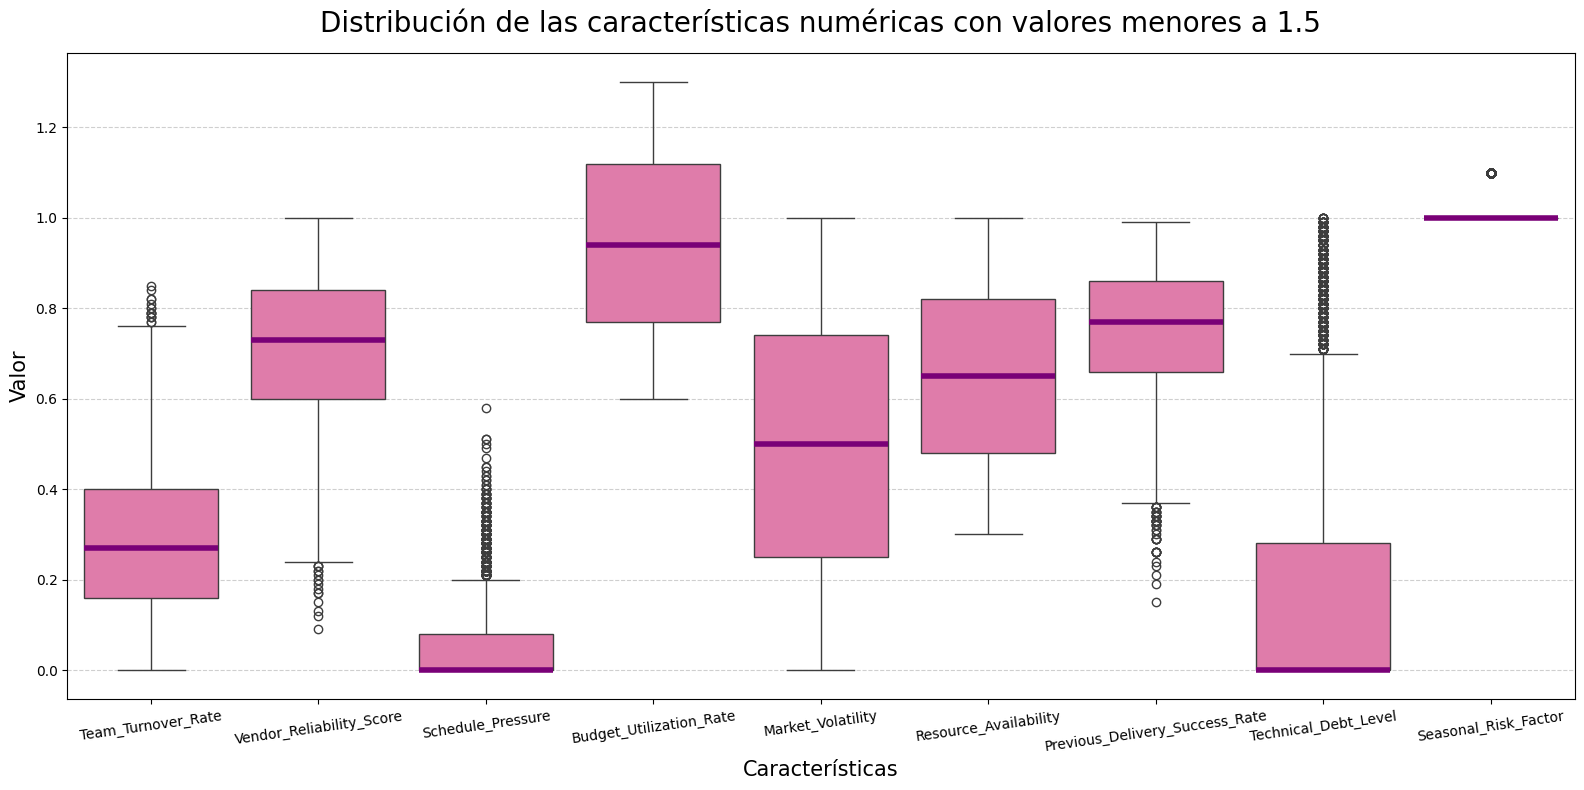

In [14]:
plt.figure(figsize=(16, 8))

df_numeric_at1 = df_numeric.iloc[:, [8,9,13,14,15,17,20,21,24]]

medprops = {'linewidth': 4, 'color': '#7A0177'}

sns.boxplot(data=df_numeric_at1, color = '#F06BA9', medianprops=medprops)

plt.title('Distribución de las características numéricas con valores menores a 1.5', fontsize=20, pad=15)
plt.xticks(rotation=8, fontsize=10)
plt.ylabel('Valor', fontsize=15)
plt.xlabel('Características', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

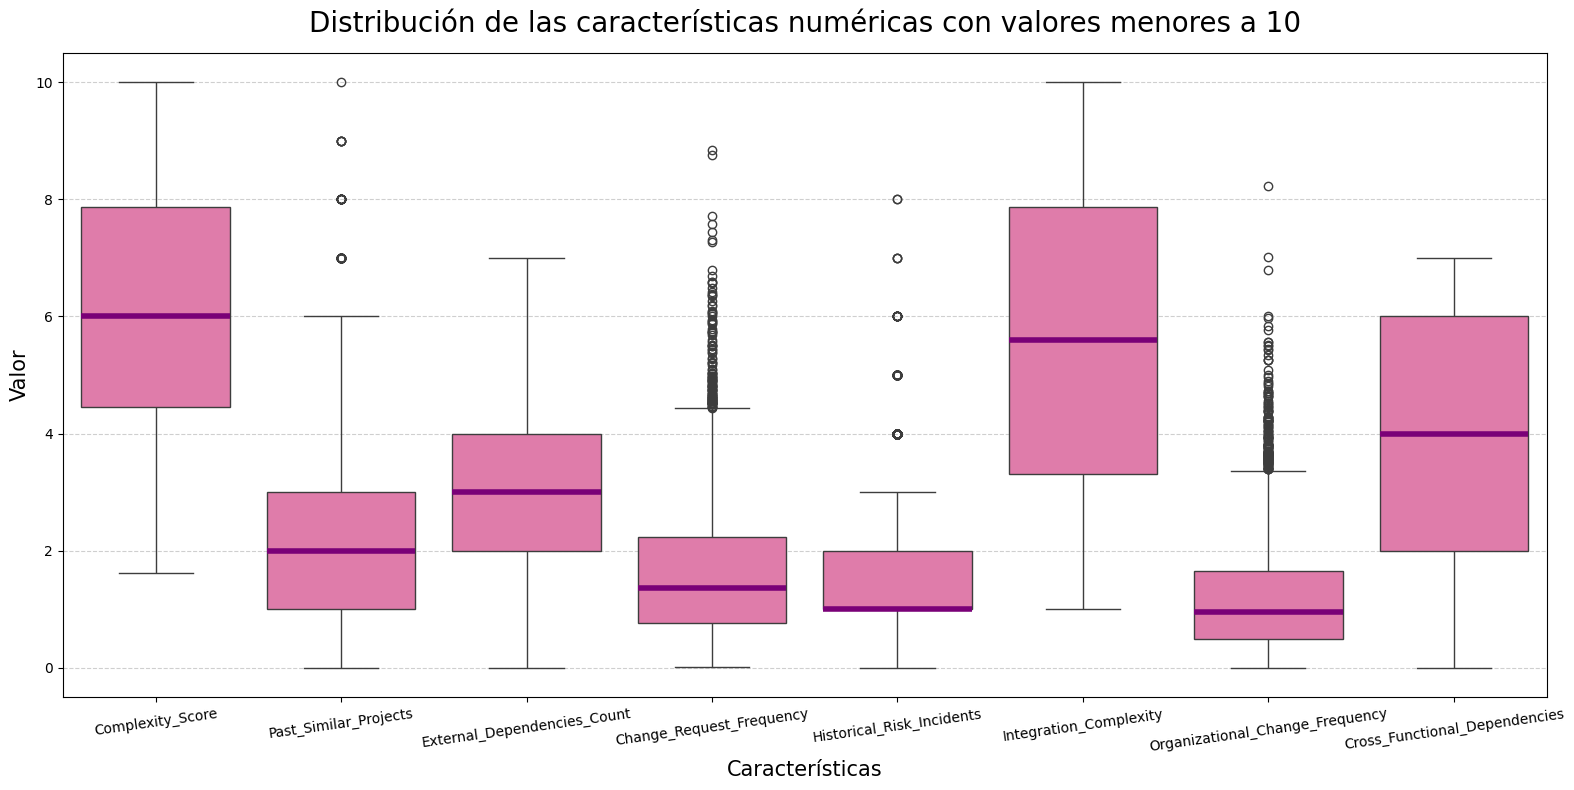

In [15]:
plt.figure(figsize=(16, 8))

df_numeric_at10 = df_numeric.iloc[:, [3,5,6,7,10,16,18,19,]]

medprops = {'linewidth': 4, 'color': '#7A0177'}

sns.boxplot(data=df_numeric_at10, color = '#F06BA9', medianprops=medprops)

plt.title('Distribución de las características numéricas con valores menores a 10', fontsize=20, pad=15)
plt.xticks(rotation=8, fontsize=10)
plt.ylabel('Valor', fontsize=15)
plt.xlabel('Características', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

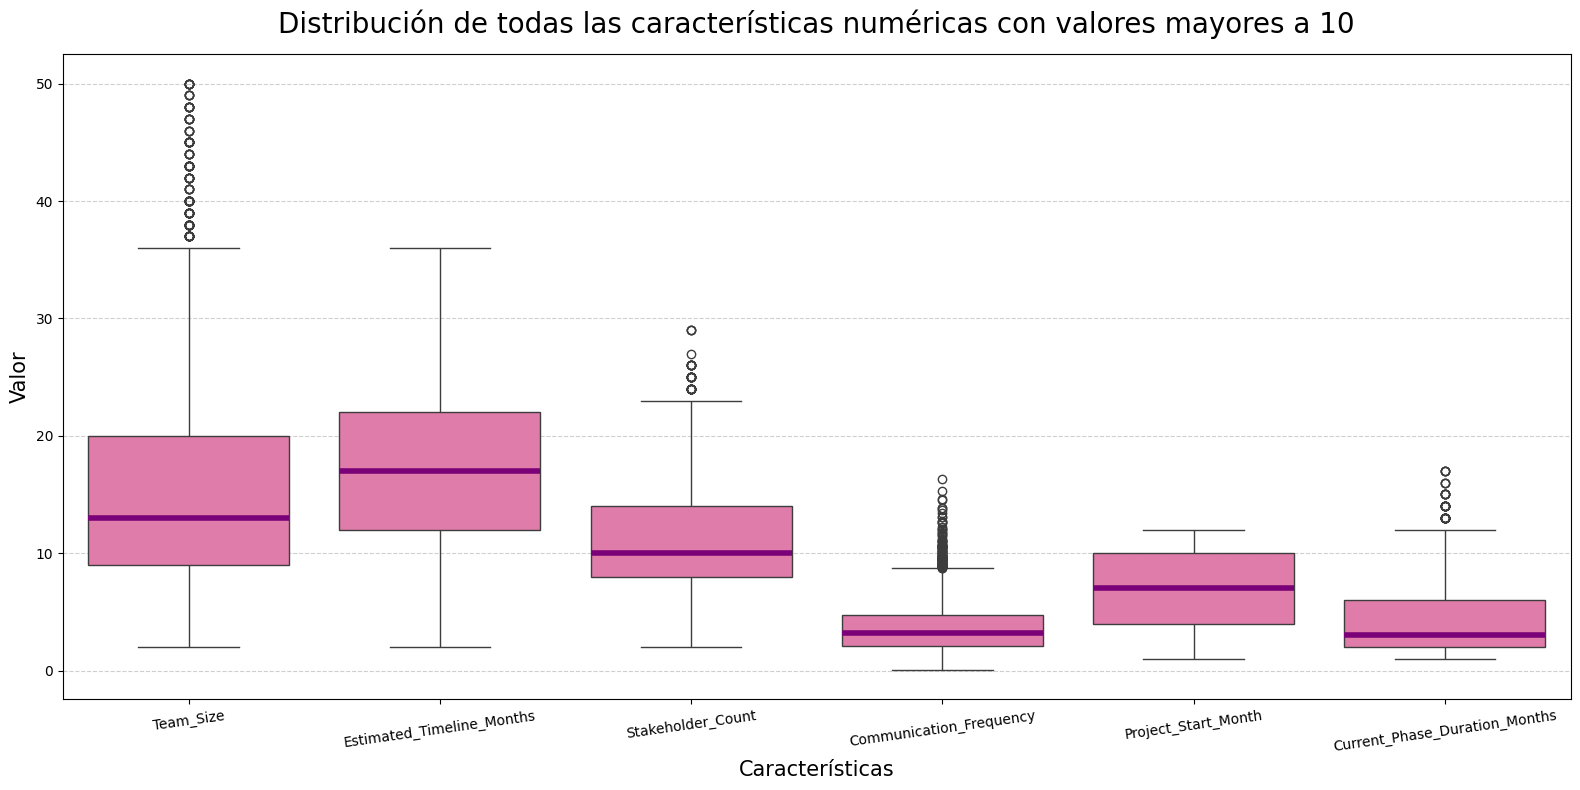

In [16]:
plt.figure(figsize=(16, 8))

df_numeric_at50 = df_numeric.iloc[:, [0,2,4,11,22,23]]

sns.boxplot(data=df_numeric_at50, color = '#F06BA9', medianprops=medprops)

plt.title('Distribución de todas las características numéricas con valores mayores a 10', fontsize=20, pad=15)
plt.xticks(rotation=8, fontsize=10)
plt.ylabel('Valor', fontsize=15)
plt.xlabel('Características', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

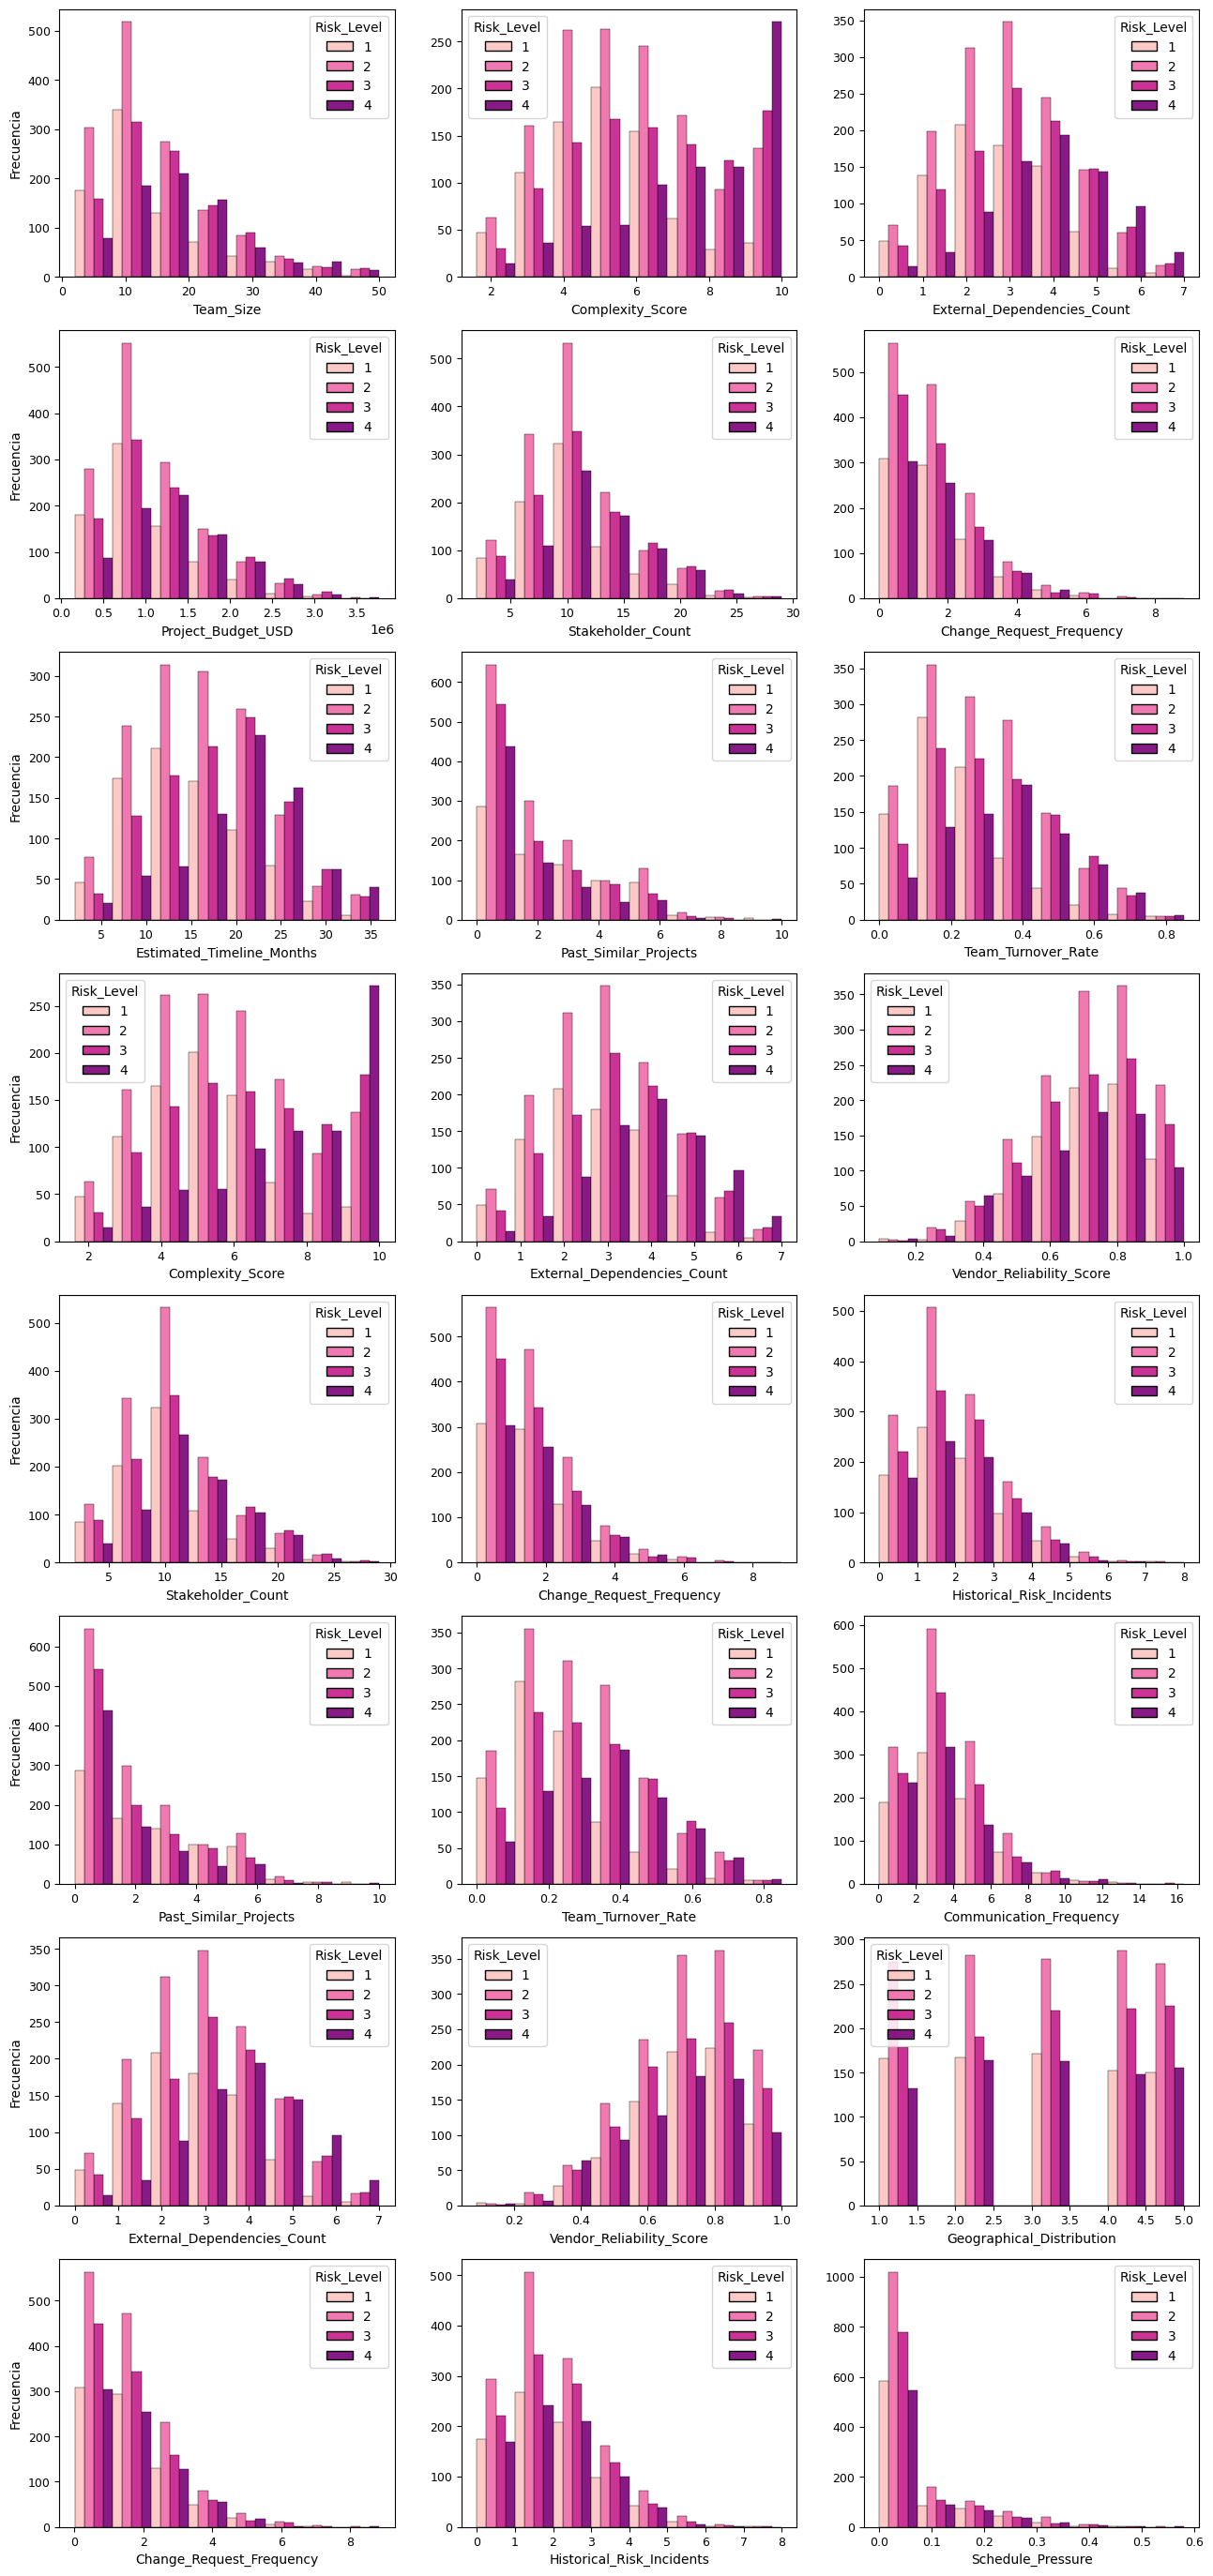

In [17]:
fig, axs = plt.subplots(8, 3)

colores = ['#FCC5C0', '#F06BA9', '#C51B8A', '#7A0177']

for i in range(8):
    for j in range(3):
        col = df_numeric.columns[3*j+i]
        sns.histplot(data=df_numeric, x=col, hue='Risk_Level', multiple='dodge',
                     palette=colores, ax=axs[i,j], bins=8, alpha=0.9)

        if j == 0:
            axs[i, j].set_ylabel('Frecuencia', fontsize=10)
        else:
            axs[i,j].set_ylabel('')
        axs[i, j].tick_params(axis='both', labelsize=9)


fig.set_size_inches(18, 15)
plt.subplots_adjust(right=0.8, top=1.9)
plt.show()

### Variables categóricas

Primero, analizamos la variable "Risk_Level" que será nuestra variable a predecir, analizando la distribución porcentual de cada riesgo y la frecuencia de ocurrencia.

Segundo, analizamos la frecuencia de ocuerencia de cada valor de las variables categóricas, mediante un gráfico de barras.

Por último, analizamos como se segmentan estas frencuencias al introducir a su vez, los distintos tipos de riesgos.

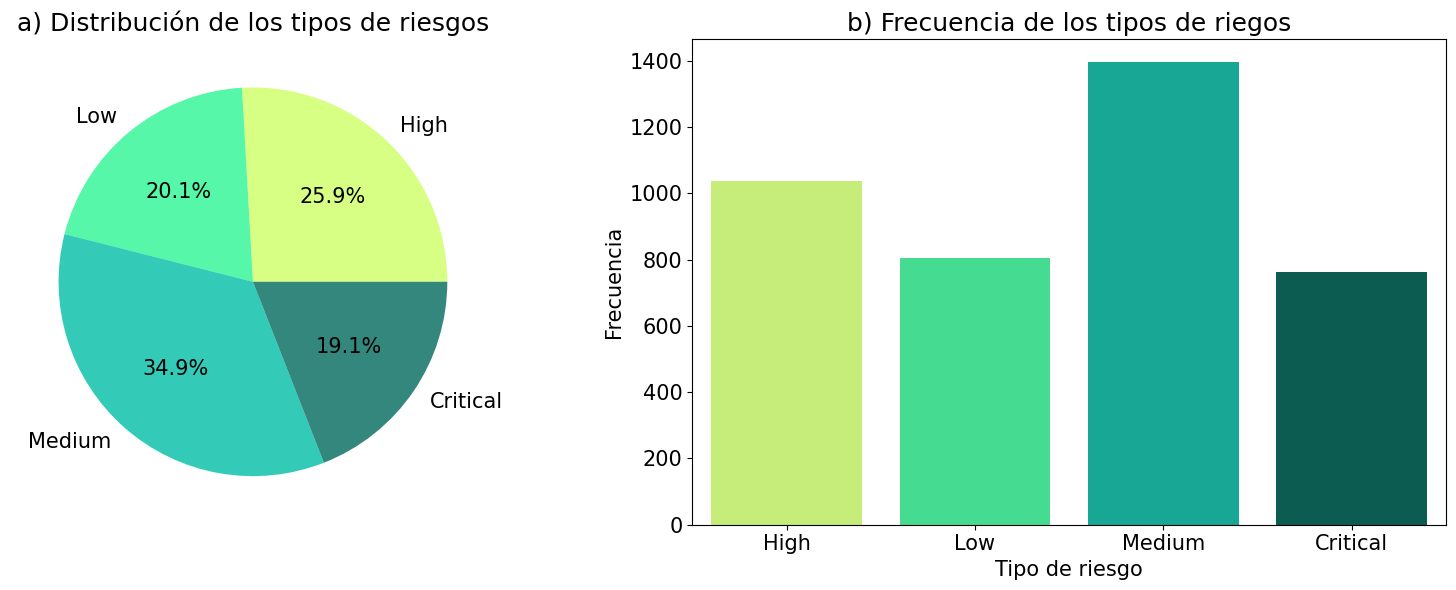

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Pie
colores = ['#CCFF66', '#2CF592', '#00BFA5', '#00695C']
colores_alpha = [to_rgba(c, alpha=0.8) for c in colores]
orden = df_category['Risk_Level'].unique()

df_category['Risk_Level'].value_counts()[orden].plot(
    kind='pie', autopct='%1.1f%%', colors=[colores_alpha[i] for i in range(len(orden))],
    ax=axes[0], textprops={'fontsize': 15},
)
axes[0].set_ylabel('')
axes[0].set_title('a) Distribución de los tipos de riesgos',fontsize=18)

# Gráfico de Barras Apiladas
sns.countplot(data=df_category, x='Risk_Level', ax=axes[1], palette=colores, hue='Risk_Level', legend=False)
axes[1].set_xlabel('Tipo de riesgo',fontsize=15)
axes[1].set_ylabel('Frecuencia',fontsize=15)
axes[1].tick_params(axis='both', labelsize=15)
axes[1].set_title('b) Frecuencia de los tipos de riegos',fontsize=18)

plt.tight_layout()
plt.show()

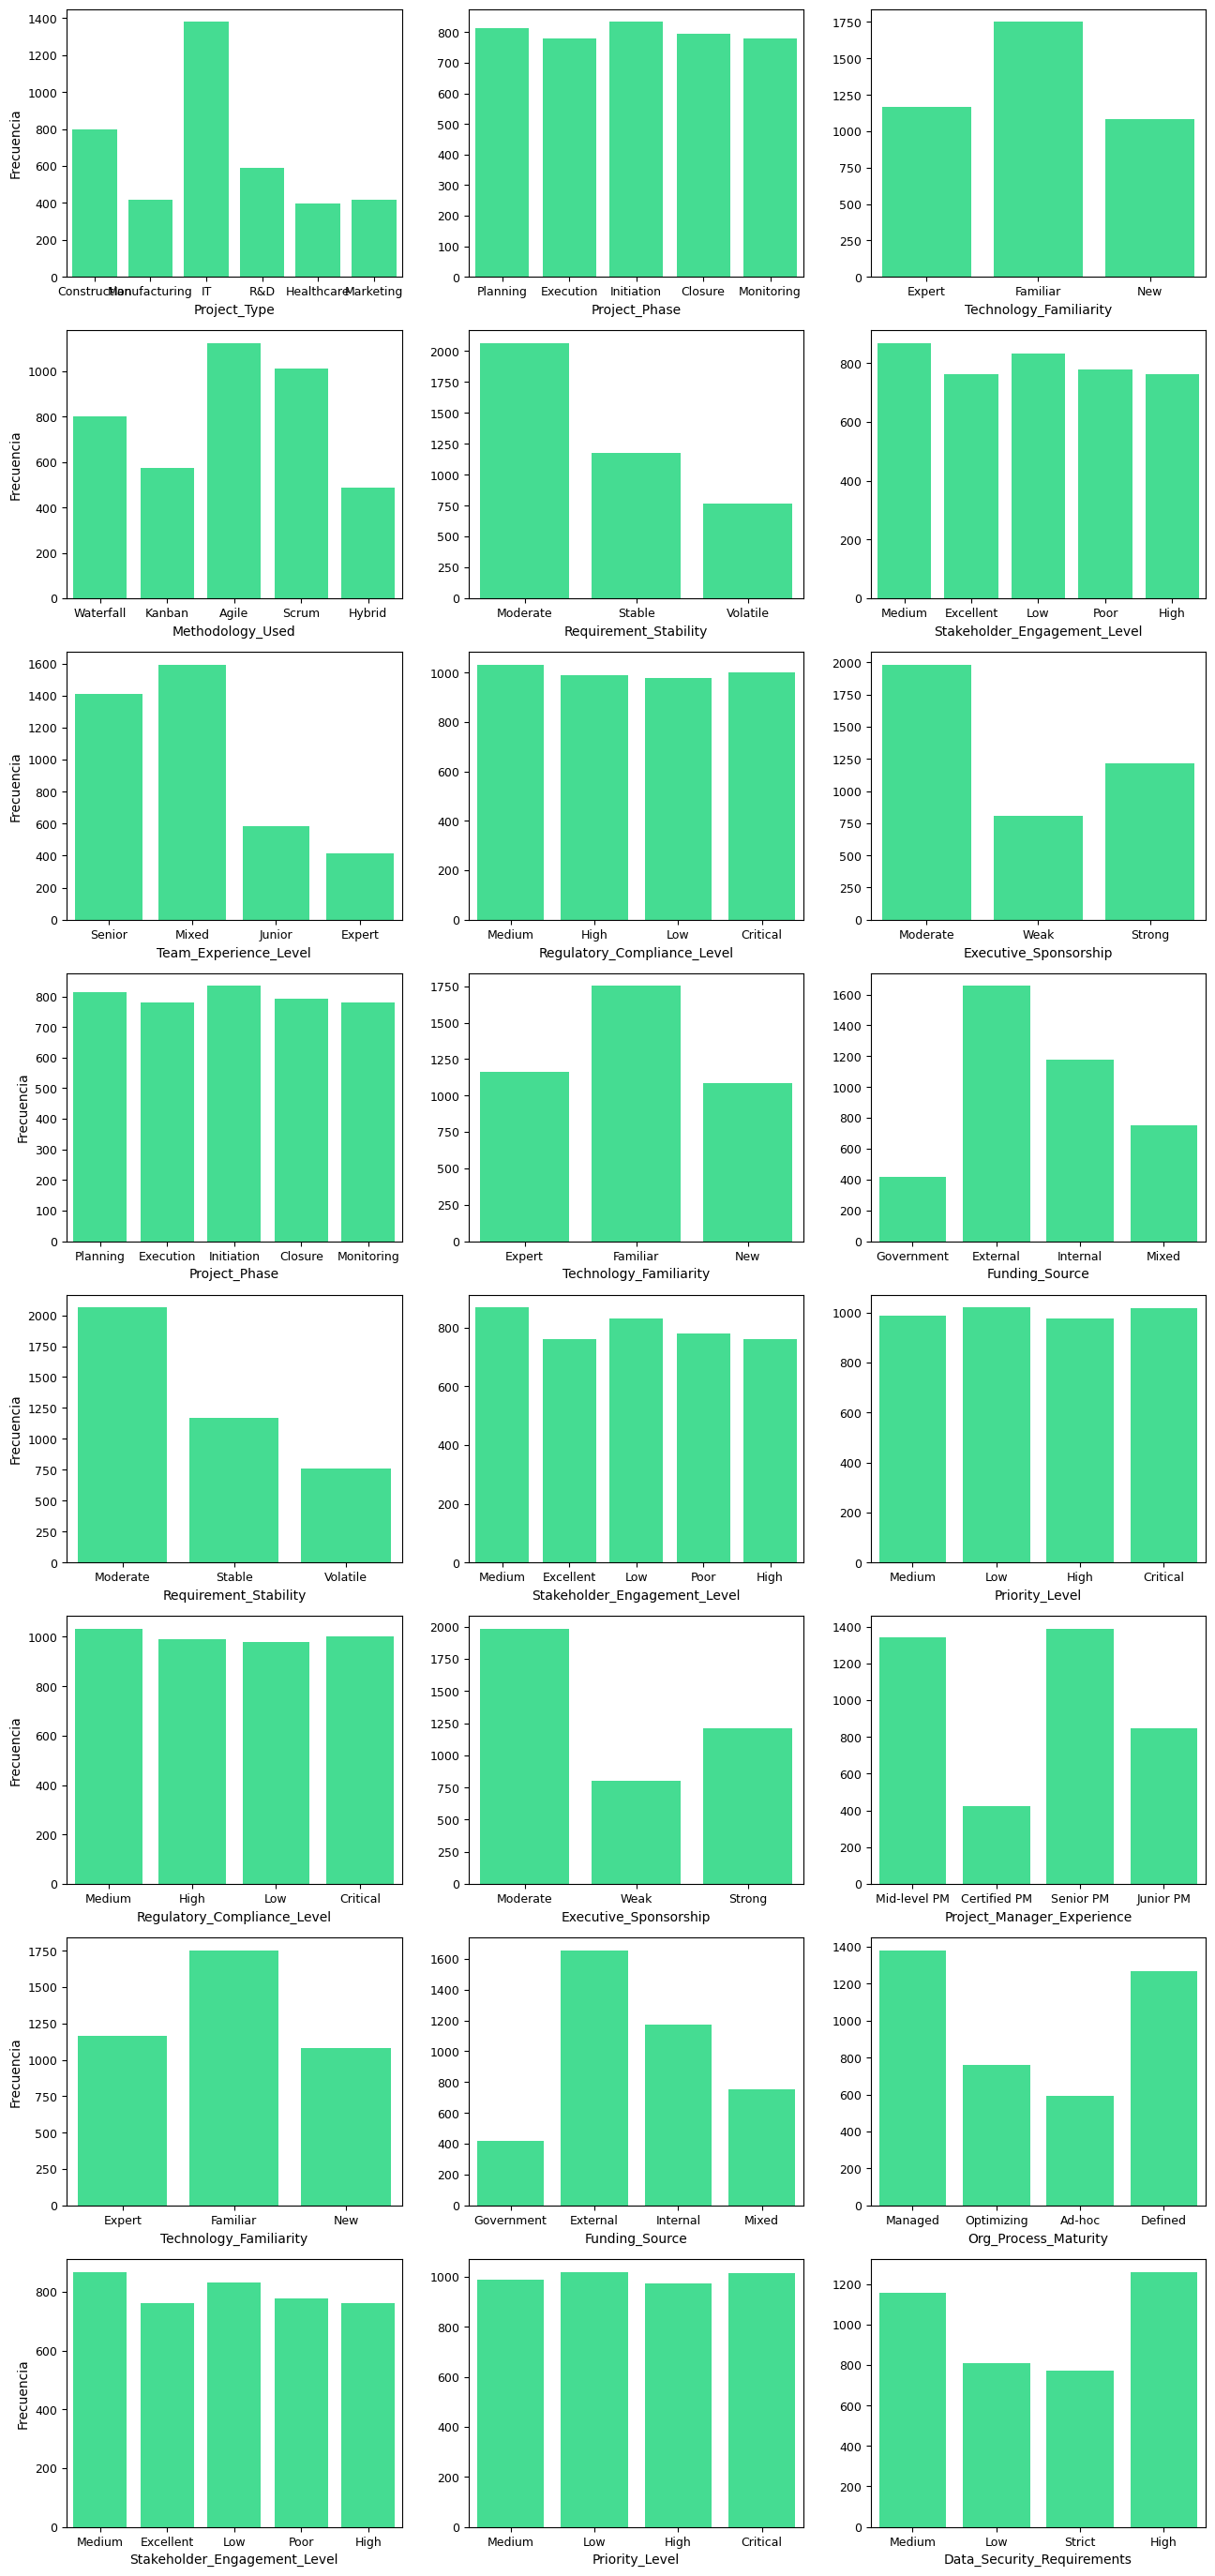

In [19]:
fig, axs = plt.subplots(8, 3)

df_category_si = df_category.drop('Project_ID', axis=1)

for i in range(8):
    for j in range(3):
        col = df_category_si.columns[3*j+i]
        sns.countplot(data=df_category, x=col, ax=axs[i, j], color='#2CF592')
        if j == 0:
            axs[i, j].set_ylabel('Frecuencia', fontsize=10)
        else:
            axs[i,j].set_ylabel('')
        axs[i, j].tick_params(axis='both', labelsize=9)


fig.set_size_inches(18, 15)
plt.subplots_adjust(right=0.8, top=1.9)
plt.show()

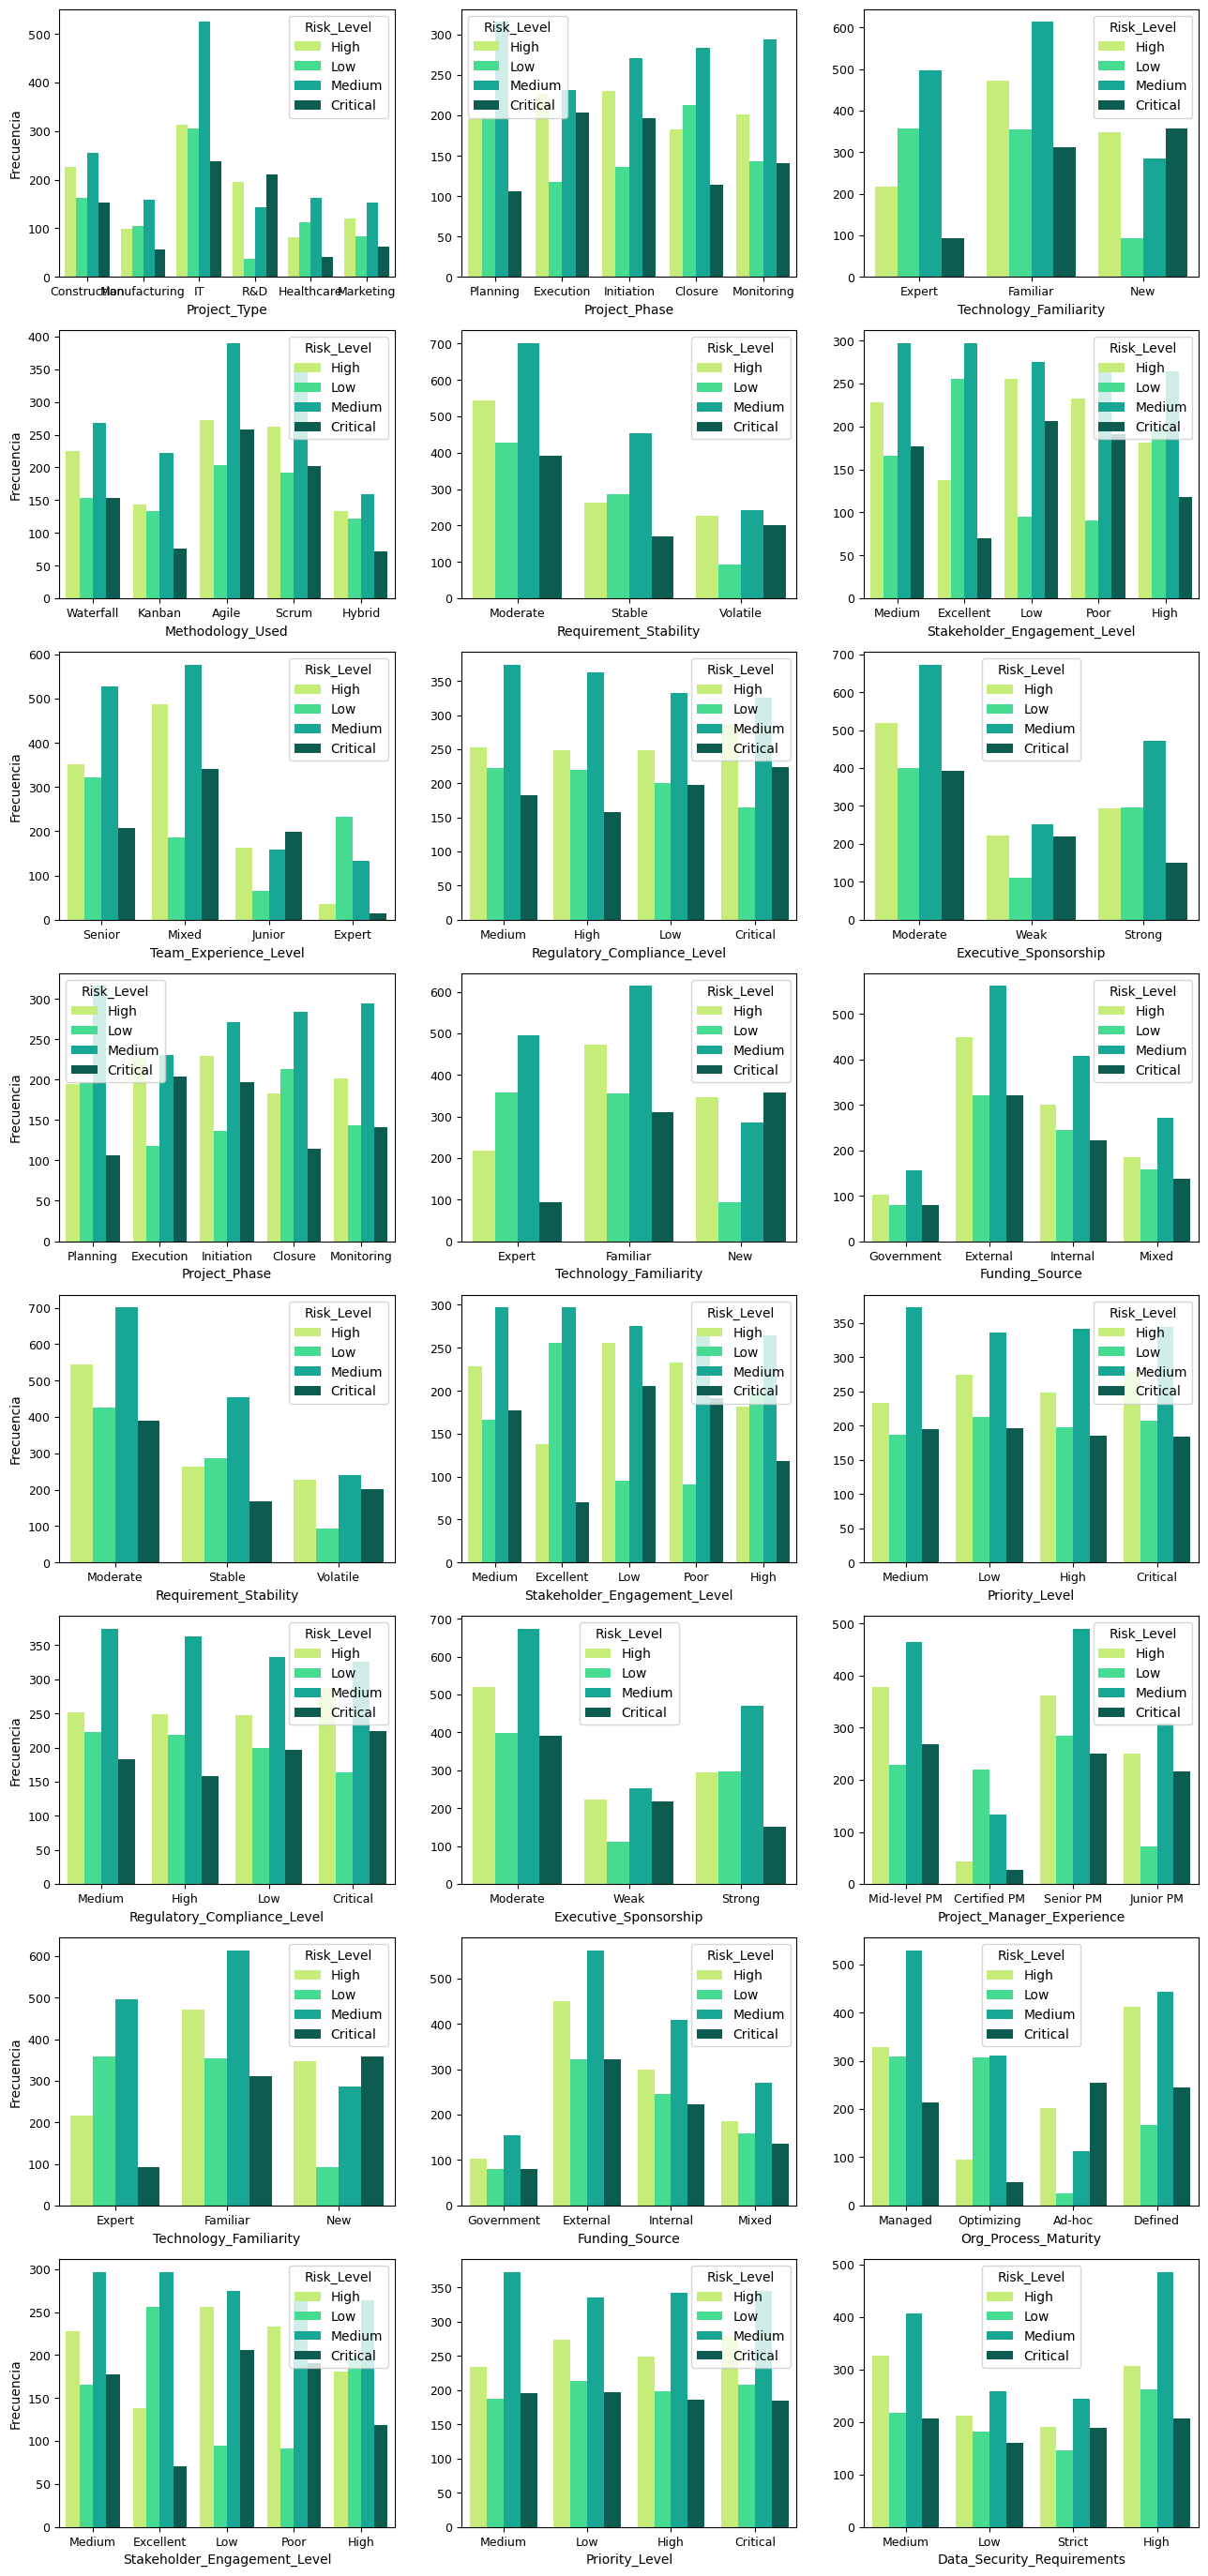

In [20]:
fig, axs = plt.subplots(8, 3)

df_category_si = df_category.drop('Project_ID', axis=1)

colores = ['#CCFF66', '#2CF592', '#00BFA5', '#00695C']

for i in range(8):
    for j in range(3):
        col = df_category_si.columns[3*j+i]
        sns.countplot(data=df_category, x=col, ax=axs[i, j], palette=colores, hue='Risk_Level')
        if j == 0:
            axs[i, j].set_ylabel('Frecuencia', fontsize=10)
        else:
            axs[i,j].set_ylabel('')
        axs[i, j].tick_params(axis='both', labelsize=9)


fig.set_size_inches(18, 15)
plt.subplots_adjust(right=0.8, top=1.9)
plt.show()